[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/Quantlets/Ch_07/TSA_ch7_seminar/TSA_ch7_seminar.ipynb)

# Time Series Analysis — Seminar 7: Cointegration and VECM

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 7; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.
- The first code cell installs the `arch` package if it is missing.

> Quantlet `TSA_ch7_seminar`: student version of the Seminar 7 notebook. Solved exercises (A1, A3, A5, B1, B3) are shown with code and output; the proposed exercises (A2, A4, A6, B2, B4, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_7'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
# The arch package (Phillips-Ouliaris test) is not preinstalled in Google Colab: pip install arch
import importlib.util, subprocess, sys
if importlib.util.find_spec('arch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])

In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- Helpers of Chapter 7 (`adf_test`, `eg_test`, `ecm_fit`, `johansen`, `cee_fx`, `stock_panel`) and the seminar functions: `eg_by_hand`, `ecm_by_hand`, `vecm_2x2`, `johansen_by_hand`, `var_to_vecm`, `b1_rates`, `b3_cee_fx`.

In [ ]:
import itertools
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, acf
from statsmodels.tsa.adfvalues import mackinnoncrit, mackinnonp
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen, select_order
from statsmodels.tsa.api import VAR
from arch.unitroot.cointegration import phillips_ouliaris
SEED = 2026
YIELDS = ['GS1', 'GS5', 'GS10']
YIELD_START = '1960-01-01'
HICP_RO = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
HICP_EA = ('prc_hicp_minr', 'M.I15.TOTAL.EA')
ROBOR = ('irt_st_m', 'M.IRT_M3.RO')
EURIBOR = ('irt_st_m', 'M.IRT_M3.EA')
CONS_RO = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.P31_S14.RO')
GDP_RO = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
BVB = ['TLV.RO', 'BRD.RO', 'SNP.RO', 'TGN.RO', 'TEL.RO', 'EL.RO', 'SNG.RO', 'SNN.RO']
US_BANKS = ['JPM.US', 'BAC.US', 'C.US', 'WFC.US', 'GS.US', 'MS.US']
PAIR = ['TLV.RO', 'BRD.RO']
PAIR_START = '2014-01-01'
FORM, TRADE, ENTRY = 252, 126, 2.0
COST_BVB, COST_US = 0.002, 0.0005


def us_yields(cols=YIELDS, start=YIELD_START):
    """US Treasury constant-maturity yields (FRED, monthly averages, % per year), monthly PeriodIndex."""
    f = read_fred(cols).dropna().loc[start:]
    f.index = pd.PeriodIndex(f.index, freq='M')
    return f


def us_macro():
    """US quarterly real GDP, consumption and investment (statsmodels macrodata, 1959Q1-2009Q3), 100 ln."""
    d = load_statsmodels('macrodata')
    return 100 * np.log(d[['realgdp', 'realcons', 'realinv']]).rename(
        columns={'realgdp': 'y', 'realcons': 'c', 'realinv': 'i'})


def cee_fx(start='2005-07-01'):
    """EUR/RON, EUR/HUF and EUR/PLN (month-end, from the BNR reference rates: EUR/HUF = EUR/RON / HUF/RON), 100 ln."""
    e, h, p = (read_reference_rate(c, start=start) for c in ('EUR', 'HUF', 'PLN'))
    d = pd.concat([e, h, p], axis=1, keys=['eur', 'huf', 'pln']).dropna()
    fx = pd.DataFrame({'EUR/RON': d.eur, 'EUR/HUF': 100 * d.eur / d.huf, 'EUR/PLN': d.eur / d.pln})
    return 100 * np.log(fx.resample('ME').last())


def stock(symbol, start):
    """Adjusted close of a stock from data/market (weekdays)."""
    t = read_market(symbol)
    s = pd.to_numeric(t['adjusted_close'], errors='coerce').loc[start:'2026-09-18'].dropna()
    s = s[s > 0]
    return s[s.index.dayofweek < 5].rename(symbol.split('.')[0])


def stock_panel(symbols, start, calendar='bet'):
    """Several stocks on a common calendar (BET or S&P 500 trading days); a missing quote is carried forward
    for at most 5 days (no trade that day), then the rows with any missing value are dropped."""
    cal = load_close(calendar, start=start).index
    P = pd.concat([stock(s, start) for s in symbols], axis=1).reindex(cal).ffill(limit=5)
    return P.dropna()


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def years_axis(ax, step=5):
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


def ts_index(x):
    """A DatetimeIndex for plotting (PeriodIndex -> timestamps)."""
    return x.index.to_timestamp() if isinstance(x.index, pd.PeriodIndex) else x.index


def adf_test(x, reg='c'):
    """ADF test (lags by AIC): statistic, MacKinnon p-value, lags, 5% critical value."""
    r = adfuller(np.asarray(pd.Series(x).dropna(), float), regression=reg, autolag='AIC')
    return {'stat': float(r[0]), 'p': float(r[1]), 'lags': int(r[2]), 'crit5': float(r[4]['5%'])}


def ols(y, X):
    """OLS with a constant: coefficients, standard errors, t-statistics, residuals, R^2, DW."""
    m = sm.OLS(np.asarray(y, float), sm.add_constant(np.asarray(X, float))).fit()
    e = m.resid
    return {'b': m.params.tolist(), 'se': m.bse.tolist(), 't': m.tvalues.tolist(), 'r2': float(m.rsquared),
            'dw': float(np.sum(np.diff(e) ** 2) / np.sum(e ** 2)), 'resid': e, 'n': int(m.nobs)}


def eg_test(y, x, trend='c'):
    """Engle-Granger two-step test: OLS of y on a constant and x (step 1), ADF on the residuals with lags by AIC
    and MacKinnon (2010) p-values for len(x)+1 variables (step 2); Phillips-Ouliaris Z_t on the same regression."""
    y = pd.Series(y)
    X = pd.DataFrame(x)
    d = pd.concat([y, X], axis=1).dropna()
    yv, Xv = d.iloc[:, 0], d.iloc[:, 1:]
    stat, p, cv = coint(yv, Xv, trend=trend, autolag='aic')
    step1 = ols(yv, Xv)
    po = phillips_ouliaris(yv, Xv, trend=trend, test_type='Zt')
    lags = adfuller(step1['resid'], regression='n', autolag='AIC')[2]
    return {'n': int(len(d)), 'beta': [float(b) for b in step1['b'][1:]], 'const': float(step1['b'][0]),
            'r2': step1['r2'], 'dw': step1['dw'], 'tau': float(stat), 'p': float(p), 'crit5': float(cv[1]),
            'crit1': float(cv[0]), 'crit10': float(cv[2]), 'lags': int(lags), 'po_zt': float(po.stat),
            'po_p': float(po.pvalue), 'po_crit5': float(po.critical_values[5]),
            'adf_crit5': float(mackinnoncrit(N=1, regression='c', nobs=len(d))[1])}


def half_life(rho):
    """Half-life (periods) of a deviation that decays like rho^h: ln(0.5)/ln(rho), for 0 < rho < 1."""
    return float(np.log(0.5) / np.log(rho)) if 0 < rho < 1 else float('inf')


def johansen(df, det_order=0, k_ar_diff=None, maxlags=8):
    """Johansen trace and maximum-eigenvalue tests (MacKinnon-Haug-Michelis critical values via statsmodels).
    k_ar_diff = lags of the differences in the VECM, by BIC on the levels VAR if None. The rank is the first r whose
    null is not rejected at 5% in the sequence r = 0, 1, ..."""
    x = df.dropna()
    if k_ar_diff is None:
        k_ar_diff = int(max(select_order(x, maxlags=maxlags, deterministic='co').bic, 1))
    r = coint_johansen(x, det_order, k_ar_diff)
    k = x.shape[1]
    rank = lambda s, c: next((i for i in range(k) if s[i] < c[i, 1]), k)
    return {'n': int(len(x)), 'k_ar_diff': k_ar_diff, 'eig': r.eig.tolist(), 'trace': r.lr1.tolist(),
            'trace_cv5': r.cvt[:, 1].tolist(), 'maxeig': r.lr2.tolist(), 'maxeig_cv5': r.cvm[:, 1].tolist(),
            'rank_trace': rank(r.lr1, r.cvt), 'rank_maxeig': rank(r.lr2, r.cvm), 'first': str(x.index[0])[:10],
            'last': str(x.index[-1])[:10]}


def ecm_fit(y, x, lags=1):
    """Single-equation ECM (two steps): e_t = y_t - a - b x_t from the levels regression, then
    Delta y_t = c + gamma e_{t-1} + delta_0 Delta x_t + sum_j (phi_j Delta y_{t-j} + delta_j Delta x_{t-j}) + eps_t."""
    d = pd.concat([pd.Series(y, name='y'), pd.Series(x, name='x')], axis=1).dropna()
    s1 = ols(d.y, d.x)
    e = pd.Series(s1['resid'], index=d.index)
    Z = pd.DataFrame({'e1': e.shift(1), 'dx': d.x.diff()})
    for j in range(1, lags + 1):
        Z[f'dy{j}'] = d.y.diff().shift(j)
        Z[f'dx{j}'] = d.x.diff().shift(j)
    Z['dy'] = d.y.diff()
    Z = Z.dropna()
    m = sm.OLS(Z.dy, sm.add_constant(Z.drop(columns='dy'))).fit()
    g = float(m.params['e1'])
    return {'beta': float(s1['b'][1]), 'a': float(s1['b'][0]), 'gamma': g, 'gamma_se': float(m.bse['e1']),
            'gamma_t': float(m.tvalues['e1']), 'delta0': float(m.params['dx']), 'delta0_se': float(m.bse['dx']),
            'const': float(m.params['const']), 'r2': float(m.rsquared), 'n': int(m.nobs), 'half': half_life(1 + g),
            'params': {k: float(v) for k, v in m.params.items()}, 'tvalues': {k: float(v) for k, v in m.tvalues.items()}}


def eg_by_hand(gamma, se, T, n_var):
    """Residual-based ADF statistic tau = gamma/SE; 5% and 10% critical values for n_var variables (MacKinnon 2010,
    with a constant) against the Dickey-Fuller value for a single series; MacKinnon p-value."""
    tau = gamma / se
    eg = mackinnoncrit(N=n_var, regression='c', nobs=T)
    df = mackinnoncrit(N=1, regression='c', nobs=T)
    return {'tau': tau, 'eg1': float(eg[0]), 'eg5': float(eg[1]), 'eg10': float(eg[2]), 'df5': float(df[1]),
            'p': float(mackinnonp(tau, regression='c', N=n_var)), 'reject_eg5': bool(tau < eg[1]),
            'reject_df5': bool(tau < df[1])}


def ecm_by_hand(c=0.2, d0=0.5, g=-0.25, b=0.9, gap=2.0, dx=1.0):
    """Delta y_t = c + d0 Delta x_t + g (y_{t-1} - b x_{t-1}): the next change for a given gap and Delta x,
    the share of the gap corrected per period and the half-life."""
    return {'dy': c + d0 * dx + g * gap, 'corr': -g, 'half': half_life(1 + g), 'part_gap': g * gap,
            'part_short': d0 * dx}


def vecm_2x2(alpha, beta):
    """Pi = alpha beta' for a bivariate VECM with one cointegrating vector; z_t = beta' y_t follows
    z_t = (1 + beta' alpha) z_{t-1} + beta' e_t: its persistence and half-life."""
    a, b = np.asarray(alpha, float), np.asarray(beta, float)
    Pi = np.outer(a, b)
    rho = 1 + b @ a
    return {'Pi': Pi.tolist(), 'rank': int(np.linalg.matrix_rank(Pi)), 'det': float(np.linalg.det(Pi)),
            'ba': float(b @ a), 'rho': float(rho), 'half': half_life(rho)}


def johansen_by_hand(eig, T, det_order=0):
    """Trace and maximum-eigenvalue statistics from the ordered eigenvalues of the Johansen problem:
    trace(r) = -T sum_{i>r} ln(1 - lambda_i), maxeig(r) = -T ln(1 - lambda_{r+1}); 5% critical values (statsmodels
    tables of MacKinnon, Haug and Michelis for k - r common trends)."""
    from statsmodels.tsa.vector_ar.vecm import c_sjt, c_sja
    lam = np.asarray(eig, float)
    k = len(lam)
    tr = [-T * np.sum(np.log(1 - lam[r:])) for r in range(k)]
    mx = [-T * np.log(1 - lam[r]) for r in range(k)]
    cvt = [float(c_sjt(k - r, det_order)[1]) for r in range(k)]
    cvm = [float(c_sja(k - r, det_order)[1]) for r in range(k)]
    rank = lambda s, c: next((i for i in range(k) if s[i] < c[i]), k)
    return {'trace': [float(v) for v in tr], 'maxeig': [float(v) for v in mx], 'cvt': cvt, 'cvm': cvm,
            'rank_trace': rank(tr, cvt), 'rank_maxeig': rank(mx, cvm)}


def var_to_vecm(A1, A2):
    """VAR(2) y_t = A1 y_{t-1} + A2 y_{t-2} + e_t written as a VECM: Pi = A1 + A2 - I, Gamma_1 = -A2; the rank of Pi
    and the roots of det(I - A1 z - A2 z^2) = 0 (a unit root for each common trend)."""
    A1, A2 = np.asarray(A1, float), np.asarray(A2, float)
    k = A1.shape[0]
    Pi = A1 + A2 - np.eye(k)
    G1 = -A2
    comp = np.block([[A1, A2], [np.eye(k), np.zeros((k, k))]])
    ev = np.linalg.eigvals(comp)
    return {'Pi': Pi.tolist(), 'Gamma1': G1.tolist(), 'rank': int(np.linalg.matrix_rank(Pi, tol=1e-10)),
            'det': float(np.linalg.det(Pi)), 'roots': sorted([float(abs(1 / v)) for v in ev if abs(v) > 1e-12])}


def b1_rates(save=True):
    """US 1-year and 10-year Treasury yields (FRED GS1, GS10, monthly, since 1960): ADF on each yield and on the
    spread, Engle-Granger and Phillips-Ouliaris (10y on 1y), the two ECM equations and the half-life."""
    f = read_fred(['GS1', 'GS10']).dropna().loc['1960-01-01':]
    out = {'n': int(len(f)), 'first': str(f.index[0])[:7], 'last': str(f.index[-1])[:7],
           'adf_gs1': adf_test(f.GS1), 'adf_gs10': adf_test(f.GS10), 'adf_dgs10': adf_test(f.GS10.diff().dropna()),
           'adf_spread': adf_test(f.GS10 - f.GS1), 'eg': eg_test(f.GS10, f.GS1), 'ecm_long': ecm_fit(f.GS10, f.GS1, lags=1)}
    e = pd.Series(ols(f.GS10, f.GS1)['resid'], index=f.index)
    import statsmodels.api as sm
    Z = pd.DataFrame({'e1': e.shift(1), 'dy1': f.GS10.diff().shift(1), 'dx1': f.GS1.diff().shift(1), 'dx': f.GS1.diff()}).dropna()
    m = sm.OLS(Z.dx, sm.add_constant(Z[['e1', 'dy1', 'dx1']])).fit()
    out['ecm_short'] = {'gamma': float(m.params['e1']), 'gamma_t': float(m.tvalues['e1'])}
    out['spread_mean'] = float((f.GS10 - f.GS1).mean())
    fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.0))
    ax[0].plot(f.index, f.GS1, color=st.MainBlue, lw=0.9, label='1-year yield')
    ax[0].plot(f.index, f.GS10, color=st.IDAred, lw=0.9, label='10-year yield')
    ax[0].set_title('US Treasury yields (% per year)')
    years_axis(ax[0], 10)
    ax[1].plot(e.index, e, color=st.Purple, lw=0.8, label='step-1 residual $\\hat e_t$')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_title(f"Residual of 10y on 1y (slope {out['eg']['beta'][0]:.2f})")
    years_axis(ax[1], 10)
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    if save:
        st.check_no_grey(fig)
        st.save_fig('ch7_sem_b1')
    else:
        plt.show()
    return out


def b3_cee_fx(save=True):
    """Johansen trace and maximum-eigenvalue tests on EUR/RON, EUR/HUF and EUR/PLN (month-end, 100 ln, since July
    2005; BIC lags); ADF on each rate and on its change; pairwise Engle-Granger tests."""
    fx = cee_fx()
    j = johansen(fx)
    out = {'johansen': j, 'adf': {c: adf_test(fx[c]) for c in fx.columns},
           'adf_d': {c: adf_test(fx[c].diff().dropna()) for c in fx.columns},
           'eg_ron_huf': eg_test(fx['EUR/RON'], fx['EUR/HUF']), 'eg_ron_pln': eg_test(fx['EUR/RON'], fx['EUR/PLN']),
           'eg_huf_pln': eg_test(fx['EUR/HUF'], fx['EUR/PLN']), 'corr_levels': float(fx.corr().iloc[0, 1]),
           'corr_changes': float(fx.diff().corr().iloc[0, 1])}
    fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.0))
    z = fx - fx.iloc[0]
    for c, col in zip(fx.columns, [st.Forest, st.Orange, st.Purple]):
        ax[0].plot(z.index, z[c], color=col, lw=1.0, label=c)
    ax[0].set_title('100 ln, July 2005 = 0')
    years_axis(ax[0], 5)
    k = len(j['trace'])
    xs = np.arange(k)
    ax[1].bar(xs - 0.18, j['trace'], width=0.36, color=st.MainBlue, label='trace statistic')
    ax[1].scatter(xs - 0.18, j['trace_cv5'], color=st.IDAred, marker='_', s=400, label='5% critical value', zorder=3)
    ax[1].bar(xs + 0.18, j['maxeig'], width=0.36, color=st.Amber, label='max-eigenvalue statistic')
    ax[1].scatter(xs + 0.18, j['maxeig_cv5'], color=st.IDAred, marker='_', s=400, label='_nolegend_', zorder=3)
    ax[1].set_xticks(xs)
    ax[1].set_xticklabels([f'$H_0$: r = {r}' if r == 0 else f'$H_0$: r $\\leq$ {r}' for r in range(k)])
    ax[1].set_title('Johansen tests')
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    if save:
        st.check_no_grey(fig)
        st.save_fig('ch7_sem_b3')
    else:
        plt.show()
    return out

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: an Engle–Granger statistic

**Context.** Two $I(1)$ series, $T = 200$; step 2 gives $\Delta\hat u_t = -0.118\,\hat u_{t-1}$, with SE $= 0.036$.

1. Compute $\tau$.
2. Compare $\tau$ with the 5% and 10% Engle–Granger values for 2 variables, and decide.
3. Say what the Dickey–Fuller value would have concluded.
4. Explain why the two critical values differ.

**Report:** one number, two decisions and one sentence.

In [8]:
# Solution
eg_by_hand(-0.118, 0.036, 200, 2)

{'tau': -3.2777777777777777,
 'eg1': -3.952037675,
 'eg5': -3.366851075,
 'eg10': -3.065724,
 'df5': -2.876102355,
 'p': 0.05785493402236041,
 'reject_eg5': False,
 'reject_df5': True}

**Interpretation of the result.** $\tau = -3.28$ lies between the Engle–Granger 5% value (about $-3.37$) and the Dickey–Fuller value (about $-2.88$): no cointegration at 5%, a rejection at 10%; the Dickey–Fuller table would wrongly report cointegration.

## A2 [Proposed]: three variables

**Context.** $y_t$ on $x_{1t}$ and $x_{2t}$, $T = 150$; $\hat\gamma = -0.162$, SE $= 0.041$. Model: A1.

1. Compute $\tau$.
2. Decide at 5% and at 1% with the values for 3 variables.
3. Say which critical value a student would wrongly use if he forgot $x_{2t}$.
4. Say how many cointegrating vectors the Engle–Granger method can find with three variables.

**Report:** one number, two decisions and two sentences.

In [ ]:
# Your code here


## A3 [Solved]: an error correction model

**Context.** $\Delta c_t = 0.2 + 0.5\,\Delta y_t - 0.25\,(c_{t-1} - 0.9\,y_{t-1})$.

1. Give the long-run and the short-run effect of income on consumption.
2. Interpret the coefficient $-0.25$ and compute the half-life.
3. Compute $\Delta c_t$ if $c_{t-1} - 0.9\,y_{t-1} = 2$ and $\Delta y_t = 1$.
4. Say what a coefficient of $+0.25$ would mean.

**Report:** two elasticities, one half-life, one forecast and one sentence.

In [10]:
# Solution
ecm_by_hand(c=0.2, d0=0.5, g=-0.25, b=0.9, gap=2.0, dx=1.0)

{'dy': 0.19999999999999996,
 'corr': 0.25,
 'half': 2.409420839653209,
 'part_gap': -0.5,
 'part_short': 0.5}

**Interpretation of the result.** A quarter of the gap closes each period (half-life 2.41 periods); here the error correction ($-0.5$) cancels the short-run effect of income ($+0.5$), so consumption grows only by the constant.

## A4 [Proposed]: a bivariate VECM

**Context.** $\Delta y_{1t} = -0.20\,z_{t-1} + u_{1t}$, $\Delta y_{2t} = 0.05\,z_{t-1} + u_{2t}$, $z_t = y_{1t} - y_{2t}$. Model: A3.

1. Write $\alpha$, $\beta$ and $\Pi = \alpha\beta^\top$, and give the rank of $\Pi$.
2. Explain which variable does most of the adjusting.
3. Show that $z_t = (1 + \beta^\top\alpha)z_{t-1} + (u_{1t} - u_{2t})$ and compute its half-life.

**Report:** one matrix, one rank, one half-life and one sentence.

In [ ]:
# Your code here


## A5 [Solved]: Johansen statistics from eigenvalues

**Context.** Three $I(1)$ series, $T = 200$, case with a constant; eigenvalues 0.120, 0.045, 0.008.

1. Compute the trace statistics for $r = 0$, $r \le 1$, $r \le 2$.
2. Compute the maximum-eigenvalue statistics.
3. Compare with the 5% values and choose the rank.
4. Give the number of common trends.

**Report:** six statistics, one rank and one number of trends.

In [12]:
# Solution
johansen_by_hand([0.120, 0.045, 0.008], 200)

{'trace': [36.3818963417112, 10.815222039734222, 1.6064343394528533],
 'maxeig': [25.566674301976978, 9.20878770028137, 1.6064343394528533],
 'cvt': [29.7961, 15.4943, 3.8415],
 'cvm': [21.1314, 14.2639, 3.8415],
 'rank_trace': 1,
 'rank_maxeig': 1}

**Interpretation of the result.** Only $r = 0$ is rejected (trace 36.38 > 29.80): rank 1, so $3 - 1 = 2$ common trends.

## A6 [Proposed]: from a VAR(2) to a VECM

**Context.** $A_1 = \begin{pmatrix} 0.7 & 0.2 \\ 0.1 & 0.7 \end{pmatrix}$, $A_2 = \begin{pmatrix} 0.1 & 0 \\ 0 & 0.2 \end{pmatrix}$. Model: A5.

1. Compute $\Pi = A_1 + A_2 - I$ and $\Gamma_1 = -A_2$.
2. Show that $\Pi$ has rank 1 and write it as $\alpha\beta^\top$ with $\beta = (1, -1)^\top$.
3. Interpret the signs of $\alpha$.

**Report:** two matrices, $\alpha$ and one sentence.

In [ ]:
# Your code here


# Part B: real data and interpretation

## B1 [Solved]: the 1-year and the 10-year US yields

**Question.** Are the 1-year and the 10-year Treasury yields cointegrated, how fast does their gap close, and which rate closes it?

1. Run ADF (with a constant) on both yields and on the change of the 10-year yield.
2. Run Engle–Granger (10-year on 1-year) and Phillips–Ouliaris, and compare with the 5% Engle–Granger value.
3. Estimate the ECM of the 10-year yield (one lag of each difference) and the same equation for the 1-year yield.
4. Interpretation: if the 10-year yield is 1 percentage point above its equilibrium, how long until half of the gap is closed, and by which rate?

**Report:** three ADF p-values, two cointegration tests, two adjustment coefficients and one sentence.

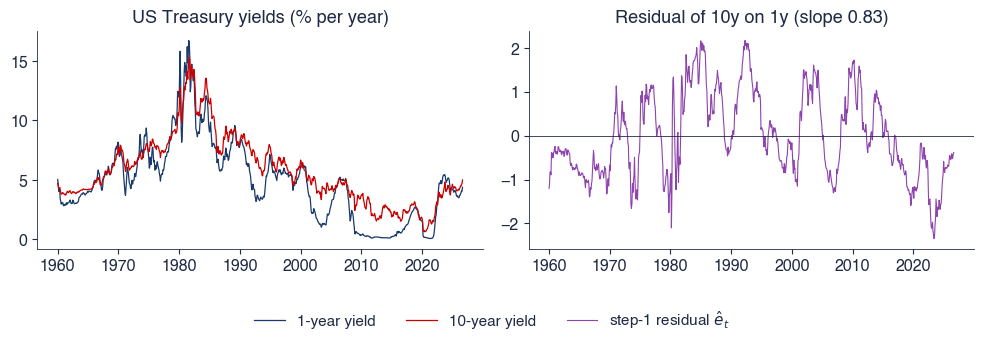

{'adf_gs1': 0.259, 'adf_gs10': 0.626, 'adf_dgs10': 0.0, 'adf_spread': 0.001}
{'tau': -3.587, 'p': 0.025, 'crit5': -3.344, 'po_zt': -3.647, 'po_p': 0.022} beta 0.827
10y: gamma -0.0295 t -4.81 half-life 23.1
1y: gamma 0.0172 t 1.25


In [14]:
# Solution
b1 = b1_rates(save=False)
print({k: round(b1[k]['p'], 3) for k in ('adf_gs1', 'adf_gs10', 'adf_dgs10', 'adf_spread')})
print({k: round(b1['eg'][k], 3) for k in ('tau', 'p', 'crit5', 'po_zt', 'po_p')}, 'beta', round(b1['eg']['beta'][0], 3))
print('10y: gamma', round(b1['ecm_long']['gamma'], 4), 't', round(b1['ecm_long']['gamma_t'], 2), 'half-life', round(b1['ecm_long']['half'], 1))
print('1y: gamma', round(b1['ecm_short']['gamma'], 4), 't', round(b1['ecm_short']['gamma_t'], 2))

**Interpretation of the result.** The yields are cointegrated; the 10-year yield closes about 3% of the gap per month (half-life of about two years), while the 1-year yield, driven by monetary policy, does not react.

## B2 [Proposed]: consumption and GDP in Romania

**Question.** Is Romanian household consumption cointegrated with GDP, as the "great ratios" suggest? Model: B1.

1. Run ADF (constant and trend) on $c_t$ and $y_t$, and ADF (constant) on their changes (`read_eurostat(*CONS_RO)`, `read_eurostat(*GDP_RO)`, as $100\ln$).
2. Run Engle–Granger ($c_t$ on $y_t$) and Phillips–Ouliaris, and report the slope.
3. Plot the ratio of consumption to GDP and run ADF on $c_t - y_t$.
4. Interpretation: does a stable consumption share make sense for Romania over 1995–2026?

**Report:** four ADF tests, two cointegration tests, one chart and two sentences.

In [ ]:
# Your code here


## B3 [Solved]: three Central European currencies

**Question.** Do EUR/RON, EUR/HUF and EUR/PLN share a long-run equilibrium?

1. Run ADF on each rate.
2. Run the Johansen trace and maximum-eigenvalue tests with a constant and lags by BIC.
3. Compare with the three pairwise Engle–Granger tests and with the correlations of levels and of changes.
4. Interpretation: should the three rates be modelled with a VECM?

**Report:** three ADF p-values, a table of six Johansen statistics, a rank and one sentence.

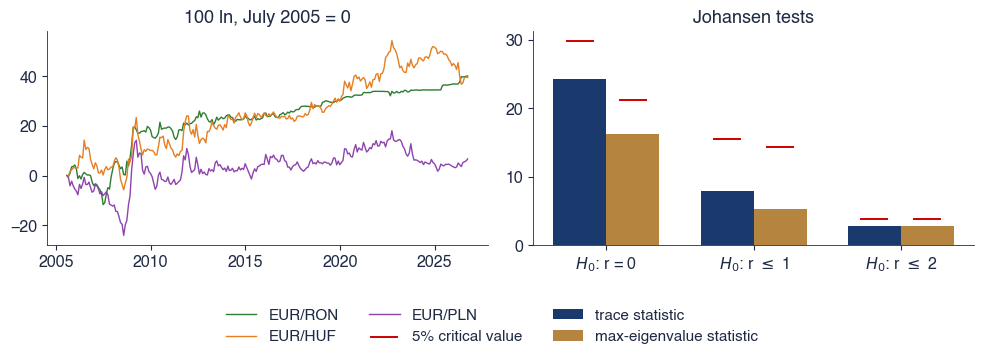

,trace,trace 5%,max-eig,max-eig 5%
r = 0,24.21,29.80,16.27,21.13
r <= 1,7.94,15.49,5.21,14.26
r <= 2,2.72,3.84,2.72,3.84


rank 0 {'EUR/RON': 0.55, 'EUR/HUF': 0.75, 'EUR/PLN': 0.08}
EG p: 0.29 0.08 0.2
correlation of levels 0.89 of changes 0.31


In [16]:
# Solution
b3 = b3_cee_fx(save=False)
j = b3['johansen']
display(pd.DataFrame({'trace': j['trace'], 'trace 5%': j['trace_cv5'], 'max-eig': j['maxeig'], 'max-eig 5%': j['maxeig_cv5']}, index=['r = 0', 'r <= 1', 'r <= 2']).round(2))
print('rank', j['rank_trace'], {k: round(v['p'], 2) for k, v in b3['adf'].items()})
print('EG p:', round(b3['eg_ron_huf']['p'], 2), round(b3['eg_ron_pln']['p'], 2), round(b3['eg_huf_pln']['p'], 2))
print('correlation of levels', round(b3['corr_levels'], 2), 'of changes', round(b3['corr_changes'], 2))

**Interpretation of the result.** Rank 0: no long-run equilibrium; a VAR in differences (Chapter 6) is the right model, although the levels are highly correlated.

## B4 [Proposed]: ROBOR, the Romanian 10-year yield and Euribor

**Question.** How many long-run relations tie Romanian interest rates to each other and to Euribor, and which rate adjusts? Model: B3.

1. Run the Johansen tests (constant, BIC lags) and choose the rank (`read_eurostat(*ROBOR)`, `read_eurostat(*EURIBOR)`, `load_close('ro10y')` as monthly means, since 2010).
2. Estimate the VECM with that rank and the constant restricted to the cointegrating relation; normalise $\beta$ on ROBOR.
3. Report $\hat\alpha$ with $t$-statistics and run ADF on the equilibrium error.
4. Interpretation: which rates are weakly exogenous, and what does this say about Romanian monetary conditions?

**Report:** a table of Johansen statistics, $\hat\beta$, $\hat\alpha$ with $t$, one ADF test and two sentences.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: pairs trading on two banks

**Question.** Would a trader who found Banca Transilvania and BRD cointegrated at the end of 2021 have earned money afterwards? Models: B1, B3.

1. On 2014–2021, run Engle–Granger and Phillips–Ouliaris (TLV on BRD) and keep $\hat b$, the mean and the standard deviation of the spread (`stock_panel(PAIR, '2014-01-01')`).
2. On January 2022–September 2026, apply the rule: open at $|z| > 2$, close at $z = 0$; compute the annual return gross and net of 0.20% per unit traded.
3. Repeat the Engle–Granger test on the trading period alone.
4. Interpretation: is the result evidence that pairs trading works on the BVB?

**Report:** two tests, the number of trades, two returns and a plan for a project.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered questions on cointegration:

- (a) the Engle–Granger statistic is $-3.0$ with two variables; since $-3.0$ is below the 5% Dickey–Fuller value, the series are cointegrated;
- (b) the ECM coefficient of the lagged equilibrium error is $+0.15$, so 15% of the gap is corrected each period;
- (c) Johansen rejects $r = 0$ and $r \le 1$ but not $r \le 2$ for three yields, so the yields share two common trends;
- (d) EUR/RON and EUR/HUF are both $I(1)$ with a high $R^2$ in levels, so they are cointegrated;
- (e) if two series are cointegrated, at least one of them Granger-causes the other;
- (f) a pairs-trading rule with a Sharpe ratio of 0.44 on 2014–2026 data will keep this Sharpe ratio in the future.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** six verdicts with one line of justification each.

In [ ]:
# Your code here
